In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM


In [149]:
data = pd.read_csv("./dataset/googleStockPrice.csv")
data.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [151]:
data['volume'] = data['Volume'] = data['Volume'].str.replace(',', '').astype(float)

In [161]:
prices = data[['Open']].values

scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

In [163]:
X = []
y = []

for i in range(60, len(prices_scaled)):
    X.append(prices_scaled[i-60:i])
    y.append(prices_scaled[i])


X = np.array(X)
y = np.array(y)

In [171]:
model = Sequential()
model.add(Input(shape=(60, 1)))
model.add(LSTM(50))
model.add(Dense(1))

In [173]:
print("Shape before:", X.shape)

Shape before: (1198, 60, 1)


In [175]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [177]:
model.fit(X, y, epochs=5, batch_size=16)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1147
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.2650e-04
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


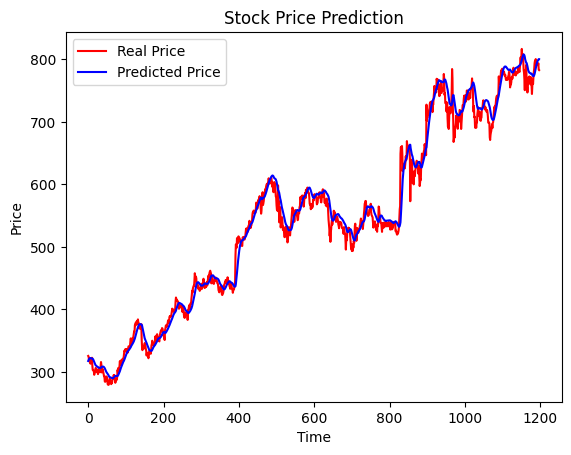

In [179]:
predicted = model.predict(X)

predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y)

import matplotlib.pyplot as plt

plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [181]:
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(real, predicted))
mae = mean_absolute_error(real, predicted)
r2 = r2_score(real, predicted)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 17.38822692926387
MAE: 12.389394083930572
R2 Score: 0.9859307435710968
